# Audit qualité du dataset maître CollectionLens

## Objectif

Évaluer la qualité du dataset maître construit à partir des différentes sources bibliographiques.

L'analyse vise à mesurer :

- la complétude des champs ;
- la couverture réelle des métadonnées ;
- la qualité des descriptions ;
- la qualité des catégories ;
- la disponibilité des couvertures ;
- la qualité des informations bibliographiques.

Cette étape permettra de déterminer si les données actuelles sont suffisantes pour les futures fonctionnalités de recommandation.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path.cwd().parents[1]

DATASET_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "master_dataset"
    / "collectionlens_master.csv"
)

df_master = pd.read_csv(DATASET_PATH)

df_master.shape

(1036, 21)

In [3]:
df_master.head()

,isbn,title,title_source,authors,authors_source,publisher,publisher_source,published_date,published_date_source,description,...,categories,categories_source,page_count,page_count_source,format,format_source,cover_url,cover_url_source,bnf_ark,bnf_ark_source
0,9782351420225,Satan 666,google_books,['Seishi Kishimoto'],google_books,Kurokawa (Paris),bnf,2005-10-13,google_books,Collection : Collection dirigée par Grégoire H...,...,NaN,NaN,184.0,google_books,"1 vol. (184 p.) : ill., couv. ill., jaquette i...",bnf,NaN,NaN,http://catalogue.bnf.fr/ark:/12148/cb40085004q,bnf
1,9782845800717,L'aube,google_books,['Osamu Tezuka'],google_books,Éd. Tonkam (Paris),bnf,2007-02-07,google_books,Le phénix est un oiseau immortel ! Une créatur...,...,NaN,NaN,339.0,google_books,"339 p. : ill., jaquette ill. en coul. ; 17 cm",bnf,NaN,NaN,http://catalogue.bnf.fr/ark:/12148/cb376291158,bnf
2,2910635169,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,9781421532271,"Color Bleach, Bleach",nudger,['Tite Kubo'],google_books,[Viz Media],nudger,2010-08-10,google_books,The Soul Reaper's Handbook This indispensable ...,...,['Comics & Graphic Novels'],google_books,184.0,nudger,Broché,nudger,http://books.google.com/books/content?id=I6Idn...,google_books,NaN,NaN
4,9782016284407,Laïcité,nudger,['Charb (1967-2015). Auteur du texte'],bnf,[Robinson],nudger,2025-01-02,google_books,"Je comprends qu&#39;on puisse être juif, chrét...",...,NaN,NaN,96.0,nudger,Album,nudger,NaN,NaN,http://catalogue.bnf.fr/ark:/12148/cb476267290,bnf


In [4]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1036 entries, 0 to 1035
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   isbn                   1036 non-null   object 
 1   title                  1000 non-null   object 
 2   title_source           1000 non-null   object 
 3   authors                850 non-null    object 
 4   authors_source         850 non-null    object 
 5   publisher              982 non-null    object 
 6   publisher_source       982 non-null    object 
 7   published_date         894 non-null    object 
 8   published_date_source  894 non-null    object 
 9   description            822 non-null    object 
 10  description_source     822 non-null    object 
 11  categories             76 non-null     object 
 12  categories_source      76 non-null     object 
 13  page_count             984 non-null    float64
 14  page_count_source      984 non-null    object 
 15  form

## Analyse de complétude

Mesure du taux de remplissage de chaque champ du dataset maître.

In [5]:
completion = []

for column in df_master.columns:

    rate = (
        df_master[column]
        .notna()
        .mean()
        * 100
    )

    completion.append(
        {
            "field": column,
            "completion_rate": round(rate, 2),
        }
    )

completion_df = pd.DataFrame(
    completion
)

completion_df.sort_values(
    "completion_rate",
    ascending=False,
)

,field,completion_rate
0,isbn,100.00
1,title,96.53
2,title_source,96.53
13,page_count,94.98
14,page_count_source,94.98
5,publisher,94.79
6,publisher_source,94.79
16,format_source,87.93
15,format,87.93
7,published_date,86.29


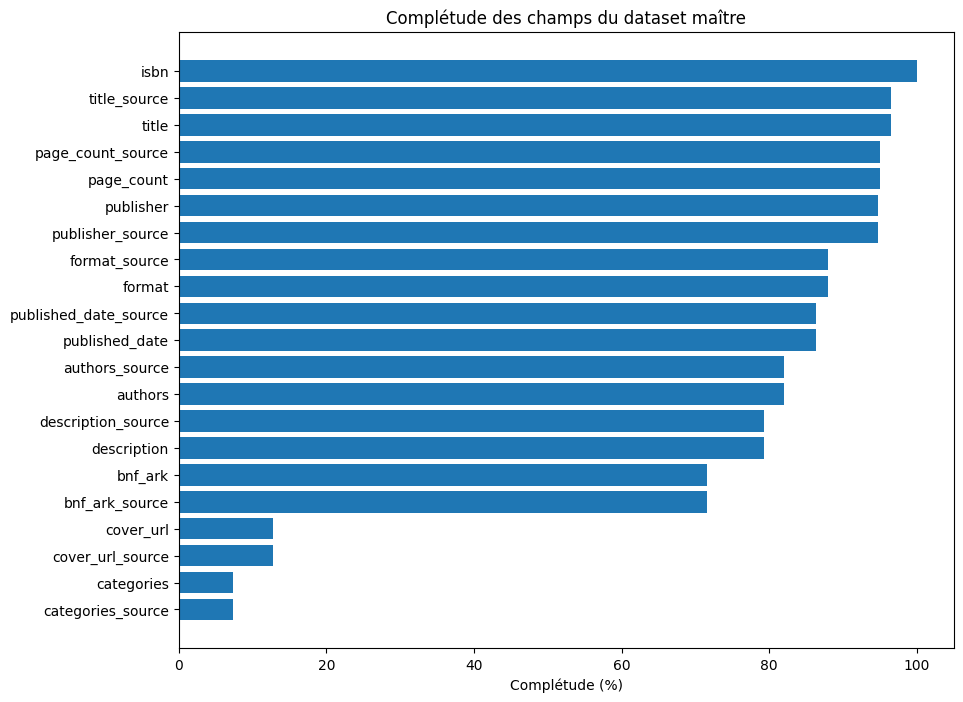

In [6]:
completion_df = completion_df.sort_values(
    "completion_rate",
    ascending=True,
)

plt.figure(figsize=(10, 8))

plt.barh(
    completion_df["field"],
    completion_df["completion_rate"],
)

plt.xlabel("Complétude (%)")
plt.title("Complétude des champs du dataset maître")

plt.show()

## Audit des features

### Analyse du champ title

Complétude observée :

- 96,53 % de titres disponibles ;
- 996 titres provenant de Nudger ;
- 4 titres provenant de Google Books ;
- 36 titres manquants.

Répartition des sources :

| Source | Nombre |
|----------|----------:|
| Nudger | 996 |
| Google Books | 4 |
| Valeur manquante | 36 |

L'analyse de l'échantillon montre que les titres sont globalement exploitables pour les futures fonctionnalités de recommandation.

Plusieurs anomalies de normalisation ont toutefois été observées :

- présence de suffixes "tome" ou "T01" ;
- mélange entre titre de série et titre de volume ;
- différences de casse ;
- présence ponctuelle d'informations éditoriales ou commerciales.

Le champ reste néanmoins de bonne qualité pour le POC.

Une normalisation complémentaire pourra être envisagée ultérieurement afin de séparer plus proprement les notions de série, volume et édition.

In [9]:
df_master["title_source"].value_counts(dropna=False)

title_source
nudger          996
NaN              36
google_books      4
Name: count, dtype: int64

In [7]:
df_master["title"].sample(
    50,
)

907                      Soyons Sérieux, Restons Idiots !
540                                                 hotel
462                                    le chant d'Apollon
104                                     Bride Stories T01
254             strange days - the apocalypse of devilman
958                                Ultimate spider-man,01
1                                                  L'aube
389                   Rooster Fighter - Coq de Baston T01
727                       unico, la petite licorne tome 1
523                                             nekomajin
916                   Et Ils Eurent Beaucoup D'emmerdes !
786         3 rue des mystères et autres histoires tome 1
229                                Le monde de Ran tome 1
816                           DC UNIVERS REBIRTH - Tome 0
555                                       rohan au louvre
718                                    shadow lady tome 1
949                                                 Alive
864           